In [2]:
import itertools
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import polars.selectors as cs
import seaborn as sns
from tqdm import tqdm

out_dir = Path("out")
out_dir.mkdir(exist_ok=True, parents=True)

pl.Config.set_tbl_rows(100)

train_df = pl.read_csv("../data/train.csv").cast({"date": pl.Date})
test_df = pl.read_csv("../data/test.csv").cast({"date": pl.Date})
gdp = pl.read_csv("../data/gdp.csv")

train_df.head()


id,date,country,store,product,num_sold
i64,date,str,str,str,f64
0,2010-01-01,"""Canada""","""Discount Stickers""","""Holographic Goose""",null
1,2010-01-01,"""Canada""","""Discount Stickers""","""Kaggle""",973.0
2,2010-01-01,"""Canada""","""Discount Stickers""","""Kaggle Tiers""",906.0
3,2010-01-01,"""Canada""","""Discount Stickers""","""Kerneler""",423.0
4,2010-01-01,"""Canada""","""Discount Stickers""","""Kerneler Dark Mode""",491.0


In [3]:
countries = train_df["country"].unique().to_list()
stores = train_df["store"].unique().to_list()
products = train_df["product"].unique().to_list()

categories = ["country", "store", "product"]
if False:
    for cat in categories:
        others = [c for c in categories if c != cat]
        out_dir_cat = out_dir / "num_sold_over_date" / cat
        shutil.rmtree(out_dir_cat, ignore_errors=True)
        out_dir_cat.mkdir(exist_ok=True, parents=True)
        for cat1, cat2 in tqdm(
            list(itertools.product(*[train_df[c].unique().to_list() for c in others]))
        ):
            df = train_df.filter(
                pl.col(others[0]).eq(cat1) & pl.col(others[1]).eq(cat2)
            )
            fig, ax = plt.subplots(figsize=(20, 8))
            sns.lineplot(df, x="date", y="num_sold", hue=cat, ax=ax)
            ax.set_title(f"{cat1} - {cat2}")
            ax.set_xlabel("Date")
            ax.set_ylabel("Number of sold products")
            fig.tight_layout()
            fig.savefig(out_dir_cat / f"{cat1}_{cat2}.png")
            fig.clear()
            plt.close(fig)


In [4]:
countries = train_df["country"].unique().to_list()
stores = train_df["store"].unique().to_list()
products = train_df["product"].unique().to_list()

categories = ["country", "store", "product"]
if False:
    out_dir_freq = out_dir / "num_sold_hist"
    shutil.rmtree(out_dir_freq, ignore_errors=True)
    out_dir_freq.mkdir(exist_ok=True, parents=True)
    for cat in categories:
        df = train_df.group_by("date", cat).agg(pl.mean("num_sold"))
        fig, ax = plt.subplots(figsize=(16, 12))
        sns.histplot(df, x="num_sold", hue=cat, kde=True, alpha=0.2, ax=ax)
        ax.set_title(f"{cat}")
        ax.set_xlabel("Number of sold products")
        ax.set_ylabel("Frequency")
        fig.tight_layout()
        fig.savefig(out_dir_freq / f"{cat}.png")
        fig.clear()
        plt.close(fig)


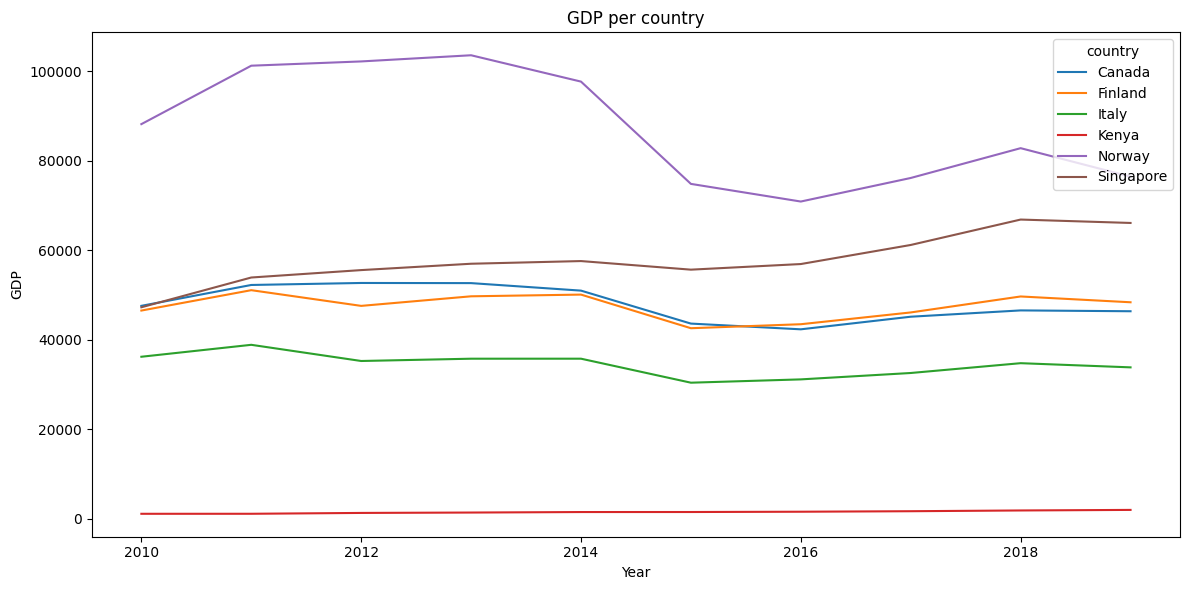

In [5]:
gdp = pl.read_csv("../data/gdp.csv")
df = gdp.unpivot(
    cs.exclude("year"),  # type: ignore
    index="year",
    variable_name="country",
    value_name="gdp",
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(df, x="year", y="gdp", hue="country", ax=ax)
ax.set_title("GDP per country")
ax.set_xlabel("Year")
ax.set_ylabel("GDP")
fig.tight_layout()

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


def plot_sales_vs_gdp(data: pl.DataFrame, gdp: pl.DataFrame, *, path: str | Path):
    df = (
        data.group_by(pl.col("date").dt.year().alias("year"), "country")
        .agg(pl.col("num_sold").mean())
        .sort("year", "country")
        .join(
            gdp.unpivot(
                cs.exclude("year"),  # type:ignore
                index="year",
                variable_name="country",
                value_name="gdp",
            ),
            on=["country", "year"],
        )
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    sns.scatterplot(df, x="gdp", y="num_sold", hue="country", ax=ax)

    X = df.select("gdp").to_numpy().reshape(-1, 1)
    y = df.select("num_sold").to_numpy()

    model = LinearRegression()
    model.fit(X, y)

    print(model.coef_, model.intercept_)

    X_plot = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    ax.plot(X_plot, y_plot, "--", color="black", alpha=0.8)

    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    correlation = np.corrcoef(X.flatten(), y.flatten())[0, 1]

    stats_text = (
        f"Linear Regression Statistics:\n"
        f"y = {model.coef_[0][0]:.4f}x + {model.intercept_.item():.4f}\n"  # type:ignore
        f"R² = {r2:.4f}\n"
        f"RMSE = {rmse:.4f}\n"
        f"Correlation = {correlation:.4f}\n"
        f"Sample size = {len(X)}"
    )

    ax.text(
        0.05,
        0.95,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    ax.set_xlabel("GDP")
    ax.set_ylabel("Number of Sales")
    ax.set_title("Sales vs GDP with Regression Line")
    ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.tight_layout()
    fig.savefig(path)
    fig.clear()
    plt.close(fig)


out_dir_gdp = out_dir / "sales_vs_gdp"
shutil.rmtree(out_dir_gdp, ignore_errors=True)
out_dir_gdp.mkdir(exist_ok=True, parents=True)
plot_sales_vs_gdp(train_df, gdp, path=out_dir_gdp / "sales_vs_gdp.png")
for store, product in itertools.product(stores, products):
    df = train_df.filter(
        pl.col("store").eq(store) & pl.col("product").eq(product)
    ).drop_nulls()
    plot_sales_vs_gdp(df, gdp, path=out_dir_gdp / f"sales_vs_gdp_{store}_{product}.png")


[[0.01560481]] [15.5680265]
[[0.00661244]] [1.46834785]
[[0.00774966]] [1.18682824]
[[0.00202985]] [1.44847398]
[[0.01211609]] [2.5842768]
[[0.01470126]] [1.53805264]
[[0.01579143]] [4.18587616]
[[0.01850249]] [4.6297941]
[[0.00489589]] [2.39885909]
[[0.02894543]] [6.95749834]
[[0.03506236]] [6.3420264]
[[0.01340416]] [2.25830299]
[[0.01569259]] [2.13478595]
[[0.00414993]] [4.77400494]
[[0.02449942]] [5.207969]
[[0.02967855]] [5.32550371]


In [8]:
import polars.selectors as cs

from polars_ml import Pipeline

drop_country_product = [
    (pl.col("country").eq(country) & pl.col("product").eq(product)).not_()
    for country, product in [
        ("Kenya", "Holographic Goose"),
        ("Kenya", "Kerneler"),
        ("Canada", "Holographic Goose"),
    ]
]


df = train_df
for predicate in drop_country_product:
    df = df.filter(predicate)

df = df.filter(pl.col("num_sold").is_not_null())

pp = (
    Pipeline()
    .to_dummies(
        ["store", "product"],
    )
    .linear.regression(
        cs.matches(r"^(store_|product_|gdp$)"),
        "num_sold",
        prediction_name="num_sold_pred_per_year",
        append_prediction=False,
    )
)
pp = (
    Pipeline()
    .group_by("year", "country", "store", "product", maintain_order=True)
    .agg(pl.col("num_sold").mean())
    .join(
        gdp.unpivot(
            cs.exclude("year"),  # type:ignore
            index="year",
            variable_name="country",
            value_name="gdp",
        ),
        on=["year", "country"],
    )
    .concat(pp, how="horizontal")
    .drop("num_sold", "gdp")
)
pp = (
    Pipeline()
    .drop("id")
    .with_columns(pl.col("date").dt.year().alias("year"))
    .join(pp, on=["country", "store", "product", "year"], how="left")
    .with_columns(
        (pl.col("num_sold") - pl.col("num_sold_pred_per_year")).alias(
            "num_sold_adjusted"
        )
    )
)
df = pp.fit_transform(df)

countries = train_df["country"].unique().to_list()
stores = train_df["store"].unique().to_list()
products = train_df["product"].unique().to_list()

categories = ["country", "store", "product"]
if False:
    # GDP -> num_soldの線形回帰は、あまりうまくいっていない
    # 考察: store, productごとにGDPとnum_soldの相関係数が異なるため
    # 対処: store, productごとにGDPとnum_soldの相関係数を計算し、それに基づいて調整する
    # 疑問: 欠損している場合はどう相関係数を決定するか
    out_dir_freq = out_dir / "num_sold_over_date_adj"
    shutil.rmtree(out_dir_freq, ignore_errors=True)
    out_dir_freq.mkdir(exist_ok=True, parents=True)
    for country, store, product in tqdm(itertools.product(countries, stores, products)):
        tmp = df.filter(
            pl.col("country").eq(country)
            & pl.col("store").eq(store)
            & pl.col("product").eq(product)
        ).sort("date")
        fig, ax = plt.subplots(figsize=(20, 8))

        sns.lineplot(tmp, x="date", y="num_sold", ax=ax)
        sns.lineplot(tmp, x="date", y="num_sold_pred_per_year", ax=ax)

        ax.set_title(f"{country} - {store} - {product}")
        ax.set_xlabel("Date")
        ax.set_ylabel("Number of sold products")
        fig.tight_layout()
        fig.savefig(out_dir_freq / f"{country}_{store}_{product}.png")
        fig.clear()
        plt.close(fig)


In [12]:
df = train_df.with_columns(pl.col("date").dt.year().alias("year"))

df.join(
    gdp.unpivot(
        cs.exclude("year"),  # type:ignore
        index="year",
        variable_name="country",
        value_name="gdp",
    ),
    on=["country", "year"],
).group_by("year", "country", "store", "product").agg(
    pl.mean("num_sold"), pl.mean("gdp")
).sort("year", "country", "store", "product")

year,country,store,product,num_sold,gdp
i32,str,str,str,f64,f64
2010,"""Canada""","""Discount Stickers""","""Holographic Goose""",null,47560.666601
2010,"""Canada""","""Discount Stickers""","""Kaggle""",666.482192,47560.666601
2010,"""Canada""","""Discount Stickers""","""Kaggle Tiers""",565.854795,47560.666601
2010,"""Canada""","""Discount Stickers""","""Kerneler""",309.958904,47560.666601
2010,"""Canada""","""Discount Stickers""","""Kerneler Dark Mode""",360.112329,47560.666601
2010,"""Canada""","""Premium Sticker Mart""","""Holographic Goose""",239.871528,47560.666601
2010,"""Canada""","""Premium Sticker Mart""","""Kaggle""",1601.008219,47560.666601
2010,"""Canada""","""Premium Sticker Mart""","""Kaggle Tiers""",1356.890411,47560.666601
2010,"""Canada""","""Premium Sticker Mart""","""Kerneler""",741.276712,47560.666601
